# 01 - Exploratory Data Analysis
Loan Default Prediction (Microfinance-framed) Capstone

Goal: understand the dataset structure, check class balance, inspect nulls, and look at relationships between features before any modeling.

## 1. Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 2. Basic Structure

In [5]:
print("Shape:", df.shape)
print()
df.info()

Shape: (255347, 18)

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LoanID,255347,255347,I38PQUQS96,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,255347.0,NaN,NaN,NaN,43.498306,14.990258,18.0,31.0,43.0,56.0,69.0
Income,255347.0,NaN,NaN,NaN,82499.304597,38963.013729,15000.0,48825.5,82466.0,116219.0,149999.0
LoanAmount,255347.0,NaN,NaN,NaN,127578.865512,70840.706142,5000.0,66156.0,127556.0,188985.0,249999.0
CreditScore,255347.0,NaN,NaN,NaN,574.264346,158.903867,300.0,437.0,574.0,712.0,849.0
MonthsEmployed,255347.0,NaN,NaN,NaN,59.541976,34.643376,0.0,30.0,60.0,90.0,119.0
NumCreditLines,255347.0,NaN,NaN,NaN,2.501036,1.117018,1.0,2.0,2.0,3.0,4.0
InterestRate,255347.0,NaN,NaN,NaN,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,NaN,NaN,NaN,36.025894,16.96933,12.0,24.0,36.0,48.0,60.0
DTIRatio,255347.0,NaN,NaN,NaN,0.500212,0.230917,0.1,0.3,0.5,0.7,0.9


## 3. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %


## 4. Duplicates

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 5. Target Class Balance — Default
This matters a lot: loan default datasets are usually imbalanced, which affects which metrics we should trust later (accuracy vs precision/recall/F1).

Default
0    225694
1     29653
Name: count, dtype: int64

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


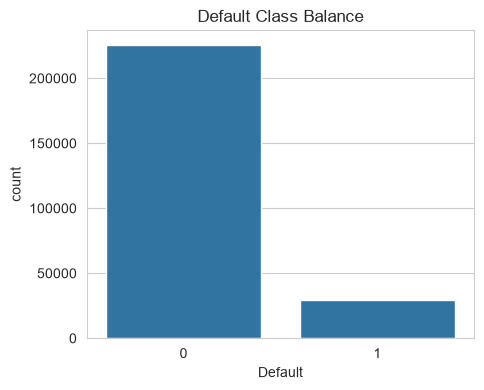

In [9]:
print(df['Default'].value_counts())
print()
print(df['Default'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x='Default', data=df)
plt.title('Default Class Balance')
plt.show()

## 6. Numeric Feature Distributions

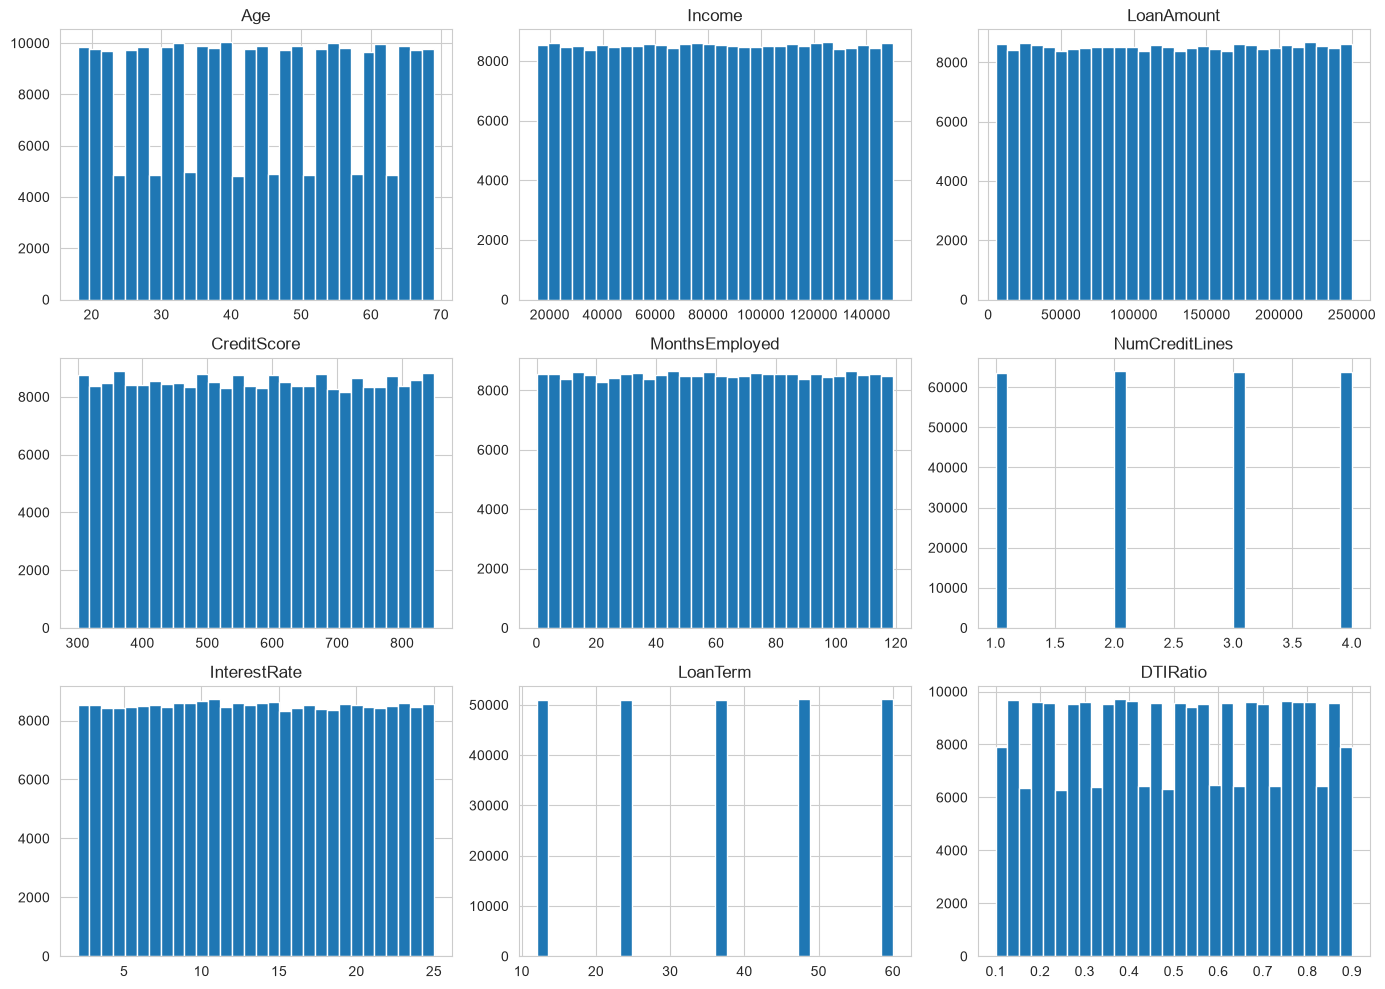

In [10]:
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

df[numeric_cols].hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

## 7. Categorical Feature Overview
Checking cardinality (unique value counts) to confirm which columns are genuinely categorical and reasonable to one-hot encode.

In [11]:
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose',
                    'HasMortgage', 'HasDependents', 'HasCoSigner']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Education ---
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

--- EmploymentType ---
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

--- LoanPurpose ---
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

--- HasMortgage ---
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

--- HasDependents ---
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

--- HasCoSigner ---
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64



## 8. Correlation Between Numeric Features
Helps flag multicollinearity — relevant later for Logistic Regression interpretation and for deciding whether PCA before clustering is worthwhile.

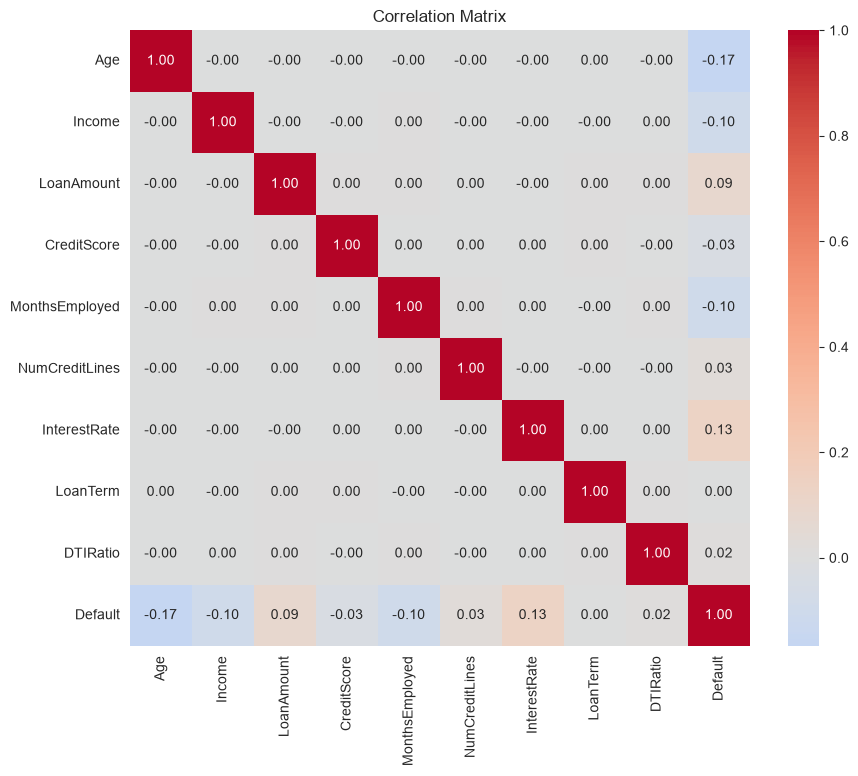

In [12]:
plt.figure(figsize=(10,8))
corr = df[numeric_cols + ['Default']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

## 9. Default Rate by Categorical Feature
Quick look at which categories are associated with higher default rates — useful context before choosing which 1-2 categorical columns to expose in the Streamlit form.

In [13]:
for col in categorical_cols:
    rate = df.groupby(col)['Default'].mean().sort_values(ascending=False)
    print(f"--- Default rate by {col} ---")
    print(rate)
    print()

--- Default rate by Education ---
Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64

--- Default rate by EmploymentType ---
EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64

--- Default rate by MaritalStatus ---
MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64

--- Default rate by LoanPurpose ---
LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64

--- Default rate by HasMortgage ---
HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64

--- Default rate by HasDependents ---
HasDependents
No     0.127244
Yes    0.105024
Name: Default, dtype: float64

--- Default rate by HasCoSigner ---
HasCoSigner
No     0.128661
Yes    0.103601

## 10. Notes / Findings
(Fill in after running: class balance %, any nulls found, which categorical columns look most predictive, any surprising correlations.)